# 03 — Debt dynamics and the decomposition of the interest burden

**Question.** Notebook 01 showed the burden falling from the mid-1990s, doubling
through the sovereign-debt crisis, and then falling again. This notebook asks
*why*, using two exact decompositions.

1. **Why the burden moved.** The interest ratio is the effective rate times the
   debt stock relative to GDP. Between any two endpoints, the change in that
   product splits exactly into a rate effect and a debt-exposure effect.
2. **Why the debt ratio moved.** The change in the debt ratio splits into the
   interest-growth differential acting on inherited debt, the primary balance,
   and the stock-flow adjustment.

Both decompositions are computed by the project library
(`pt_debt_interest.interest_decomposition` and `metrics.calculate_metrics`) and
persisted into the dataset. This notebook **verifies** them — reproducing the
first from the library function and checking both residuals against zero — and
then interprets them. It does not reimplement the formulas, so the notebook and
the generated paper cannot drift apart.

**Scope.** Harmonised ESA 2010 rows only. Lagged terms are undefined in the
first year and are dropped rather than imputed — see
[02 — data quality](02_data_quality_and_provenance.ipynb).

In [1]:
# Run correctly whether the kernel starts in notebooks/ or the repository root.
# Importing nbtools then puts src/ on the path, so pt_debt_interest is
# importable from a plain checkout without an editable install.
import sys
from pathlib import Path

_HERE = Path.cwd() if (Path.cwd() / "nbtools.py").is_file() else Path.cwd() / "notebooks"
if str(_HERE) not in sys.path:
    sys.path.insert(0, str(_HERE))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

import nbtools as nb
from pt_debt_interest.interest_decomposition import (
    build_interest_burden_counterfactuals,
    build_interest_burden_decomposition,
    build_interest_burden_decomposition_inputs,
    validate_decomposition_reconciliation,
)

nb.use_style()
ROOT = nb.repo_root()

df = nb.observed(nb.main_series(nb.load_dataset(ROOT)))
settings = nb.load_settings(ROOT)

print(f"Rows: {len(df)}  years: {int(df['year'].min())}-{int(df['year'].max())}")
print(f"Identity tolerance in config: {settings.analysis.identity_tolerance_pp} pp")

Rows: 31  years: 1995-2025
Identity tolerance in config: 0.05 pp


## 1. There are two effective interest rates, and they answer different questions

The dataset carries both, named for what they are for rather than collapsed into
one ambiguous "implicit rate":

| Column | Denominator | Used for |
| --- | --- | --- |
| `average_debt_interest_rate_pct` | mean of debt at *t-1* and *t* | the cost of the stock actually outstanding during the year |
| `debt_dynamics_interest_rate_pct` | debt at *t-1* | the debt-dynamics identity, which accrues interest on inherited debt |

Using the wrong one silently breaks whichever identity it feeds. The two differ
by roughly half the year's growth in the stock, so they diverge exactly when the
debt stock is moving fast — which is when the decomposition matters most.

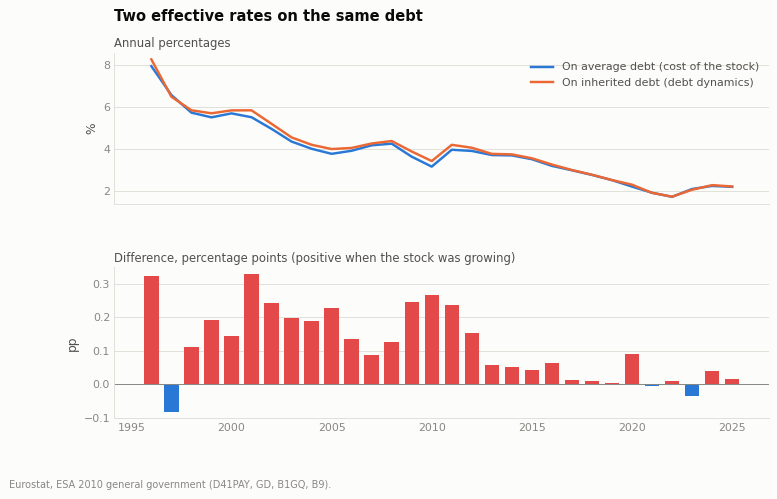

Largest gap: 0.33 pp in 2001


In [3]:
rates = df.dropna(subset=["average_debt_interest_rate_pct"]).copy()
rates["difference_pp"] = (
    rates["debt_dynamics_interest_rate_pct"] - rates["average_debt_interest_rate_pct"]
)

fig, axes = nb.figure(height=5.4, nrows=2, sharex=True)

axes[0].plot(
    rates["year"],
    rates["average_debt_interest_rate_pct"],
    color=nb.SERIES[0],
    label="On average debt (cost of the stock)",
)
axes[0].plot(
    rates["year"],
    rates["debt_dynamics_interest_rate_pct"],
    color=nb.SERIES[1],
    label="On inherited debt (debt dynamics)",
)
axes[0].legend(loc="upper right")
nb.finish(
    axes[0],
    title="Two effective rates on the same debt",
    subtitle="Annual percentages",
    ylabel="%",
    source="",
)

axes[1].bar(
    rates["year"],
    rates["difference_pp"],
    color=nb.signed_colors(rates["difference_pp"]),
    width=0.72,
)
axes[1].axhline(0, color=nb.MUTED, linewidth=0.8)
nb.finish(
    axes[1],
    subtitle="Difference, percentage points (positive when the stock was growing)",
    ylabel="pp",
)
fig.subplots_adjust(hspace=0.42)
plt.show()

widest = int(rates.loc[rates["difference_pp"].abs().idxmax(), "year"])
print(f"Largest gap: {rates['difference_pp'].abs().max():.2f} pp in {widest}")

## 2. Why the burden moved: rate against exposure

Write the burden as $b = r \cdot d$, the average-debt rate times average debt
over GDP. Between two endpoints the change splits exactly into two terms:

$$b_1 - b_0 = \underbrace{\frac{d_1 + d_0}{2}\,(r_1 - r_0)}_{\text{rate effect}}
\; + \; \underbrace{\frac{r_1 + r_0}{2}\,(d_1 - d_0)}_{\text{debt-exposure effect}}$$

There is no interaction term left over. The cross term is split evenly between
the two effects by evaluating each at the midpoint of the other — a symmetric
attribution, which is why the identity closes with exactly two components.

Two things follow for how this is read. It is an **endpoint** comparison, so it
answers "over this period" and not "in this year"; a period whose endpoints
happen to match can conceal a large excursion in between. And the burden is
rebuilt from euro interest and euro GDP, so rounding in the published percentage
ratios cannot contaminate the identity — the notebook reports that gap rather
than hiding it.

In [4]:
# Recompute from the library and confirm it matches what the pipeline persisted.
stored = nb.load_decomposition(ROOT)
recomputed = build_interest_burden_decomposition(df)

effects = ["total_change_pp", "rate_effect_pp", "debt_exposure_effect_pp"]
merged = stored[["start_year", "end_year", *effects]].merge(
    recomputed[["start_year", "end_year", *effects]],
    on=["start_year", "end_year"],
    suffixes=("_stored", "_recomputed"),
)
reproduction_error = max(
    (merged[f"{name}_stored"] - merged[f"{name}_recomputed"]).abs().max() for name in effects
)

# The library ships its own identity check; use it rather than a hand-rolled one.
validate_decomposition_reconciliation(stored)

print(f"Intervals in the persisted decomposition    : {len(stored)}")
print(f"Stored versus recomputed, largest difference: {reproduction_error:.3e} pp")
print(
    "Largest reconciliation error                : "
    f"{stored['decomposition_reconciliation_error_pp'].abs().max():.3e} pp"
)
assert reproduction_error < 1e-12, "persisted decomposition does not match the library"

Intervals in the persisted decomposition    : 8
Stored versus recomputed, largest difference: 9.992e-15 pp
Largest reconciliation error                : 6.939e-16 pp


### The two ingredients

The rate is in section 1. Its partner is *average debt exposure* — the mean of
the opening and closing debt stock, over GDP. It is not the headline end-year
debt ratio, and substituting the headline ratio here would break the identity.

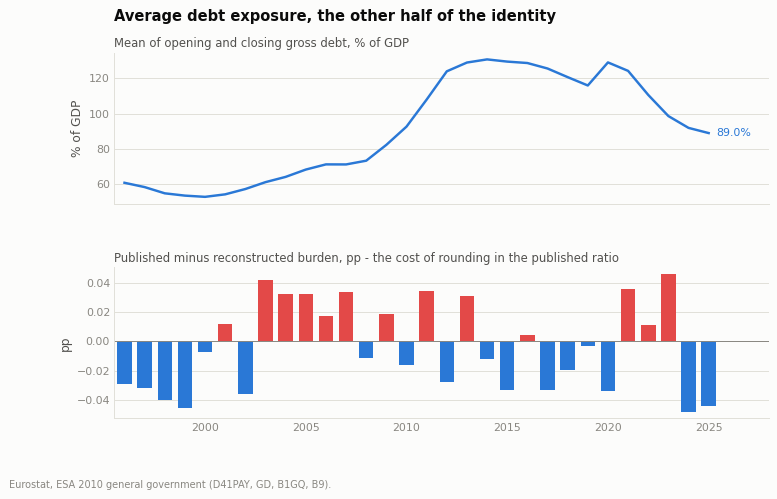

Largest rounding gap: 0.048 pp of GDP


In [5]:
inputs = build_interest_burden_decomposition_inputs(df).set_index("year")
usable = inputs.dropna(subset=["average_debt_ratio_pct_gdp"])

fig, axes = nb.figure(height=5.4, nrows=2, sharex=True)

axes[0].plot(usable.index, usable["average_debt_ratio_pct_gdp"], color=nb.SERIES[0])
nb.label_last_point(
    axes[0],
    usable.index,
    usable["average_debt_ratio_pct_gdp"],
    "",
    nb.SERIES[0],
    "{:.1f}%",
)
axes[0].set_xlim(usable.index.min() - 0.5, usable.index.max() + 3.0)
nb.finish(
    axes[0],
    title="Average debt exposure, the other half of the identity",
    subtitle="Mean of opening and closing gross debt, % of GDP",
    ylabel="% of GDP",
    source="",
)

difference = (
    inputs["official_interest_burden_pct_gdp"] - inputs["reconstructed_interest_burden_pct_gdp"]
)
axes[1].bar(
    difference.index,
    difference.to_numpy(),
    color=nb.signed_colors(difference.to_numpy()),
    width=0.72,
)
axes[1].axhline(0, color=nb.MUTED, linewidth=0.8)
nb.finish(
    axes[1],
    subtitle=(
        "Published minus reconstructed burden, pp - the cost of rounding in the published ratio"
    ),
    ylabel="pp",
)
fig.subplots_adjust(hspace=0.42)
plt.show()

print(f"Largest rounding gap: {difference.abs().max():.3f} pp of GDP")

### Sub-period attribution

The configured intervals include both contiguous sub-periods and two longer
summary spans that contain them. They are separated here: adding a span to its
own constituent parts would double-count.

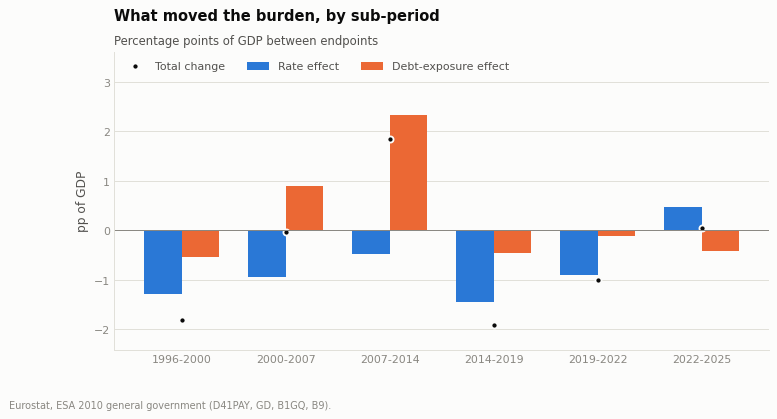

,start_reconstructed_burden_pct_gdp,end_reconstructed_burden_pct_gdp,total_change_pp,rate_effect_pp,debt_exposure_effect_pp,dominant_effect
period,,,,,,
1996-2000,4.83,3.01,-1.82,-1.28,-0.54,rate
2000-2007,3.01,2.97,-0.04,-0.94,0.90,rate
2007-2014,2.97,4.81,1.85,-0.49,2.33,debt_exposure
2014-2019,4.81,2.90,-1.91,-1.45,-0.46,rate
2019-2022,2.90,1.89,-1.01,-0.90,-0.11,rate
2022-2025,1.89,1.94,0.06,0.48,-0.42,rate


In [6]:
def _is_summary(row):
    inside = (stored["start_year"] >= row["start_year"]) & (stored["end_year"] <= row["end_year"])
    same = (stored["start_year"] == row["start_year"]) & (stored["end_year"] == row["end_year"])
    return bool((inside & ~same).any())


stored = stored.assign(is_summary_span=stored.apply(_is_summary, axis=1))
periods = stored.loc[~stored["is_summary_span"]].reset_index(drop=True)
spans = stored.loc[stored["is_summary_span"]].reset_index(drop=True)

report_columns = [
    "start_reconstructed_burden_pct_gdp",
    "end_reconstructed_burden_pct_gdp",
    "total_change_pp",
    "rate_effect_pp",
    "debt_exposure_effect_pp",
    "dominant_effect",
]


def _interval_labels(frame):
    return [f"{int(row.start_year)}-{int(row.end_year)}" for row in frame.itertuples()]


fig, ax = nb.figure(height=4.4)
positions = np.arange(len(periods))
width = 0.36
ax.bar(
    positions - width / 2,
    periods["rate_effect_pp"],
    width=width,
    color=nb.SERIES[0],
    label="Rate effect",
)
ax.bar(
    positions + width / 2,
    periods["debt_exposure_effect_pp"],
    width=width,
    color=nb.SERIES[1],
    label="Debt-exposure effect",
)
ax.plot(
    positions,
    periods["total_change_pp"],
    color=nb.INK,
    linewidth=0,
    marker="o",
    markersize=5,
    markeredgecolor=nb.SURFACE,
    markeredgewidth=1.5,
    label="Total change",
)
ax.axhline(0, color=nb.MUTED, linewidth=0.8)
ax.set_xticks(positions)
ax.set_xticklabels(_interval_labels(periods), fontsize=9)
nb.headroom(ax, top=1.42, bottom=1.14)
ax.legend(loc="upper left", ncol=3)
nb.finish(
    ax,
    title="What moved the burden, by sub-period",
    subtitle="Percentage points of GDP between endpoints",
    ylabel="pp of GDP",
)
plt.show()

periods.set_index(pd.Index(_interval_labels(periods), name="period"))[report_columns]

In [7]:
spans.set_index(pd.Index(_interval_labels(spans), name="span"))[report_columns]

,start_reconstructed_burden_pct_gdp,end_reconstructed_burden_pct_gdp,total_change_pp,rate_effect_pp,debt_exposure_effect_pp,dominant_effect
span,,,,,,
2014-2025,4.81,1.94,-2.87,-1.64,-1.22,rate
1996-2025,4.83,1.94,-2.88,-4.31,1.42,rate


### Cross-rate counterfactuals

The decomposition says which effect dominated. The counterfactual says what the
burden would have been holding one input at its old value — the same arithmetic
read from the other side. It is a bookkeeping exercise, not a claim about what
would have happened: a different rate implies different conditions, and so a
different debt stock.

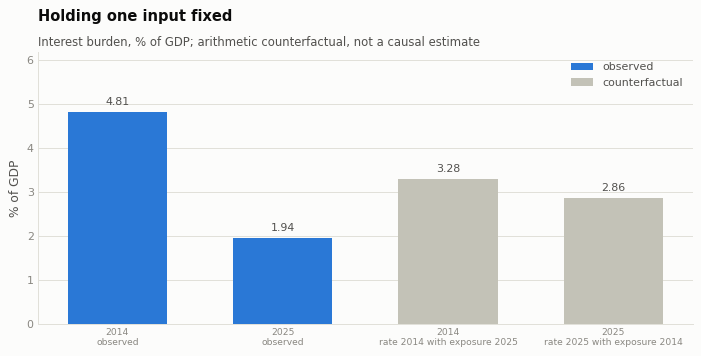

,year,average_debt_rate,average_debt_exposure,interest_burden_pct_gdp
counterfactual,,,,
observed,2014,0.04,1.31,4.81
observed,2025,0.02,0.89,1.94
rate_2014_with_exposure_2025,2014,0.04,0.89,3.28
rate_2025_with_exposure_2014,2025,0.02,1.31,2.86


In [8]:
counterfactuals = build_interest_burden_counterfactuals(df)

fig, ax = nb.figure(height=4.0)
positions = np.arange(len(counterfactuals))
is_observed = counterfactuals["counterfactual"].eq("observed").to_numpy()
ax.bar(
    positions,
    counterfactuals["interest_burden_pct_gdp"],
    color=[nb.SERIES[0] if flag else nb.RECEDED for flag in is_observed],
    width=0.6,
)
for position, value in enumerate(counterfactuals["interest_burden_pct_gdp"]):
    ax.annotate(
        f"{value:.2f}",
        xy=(position, value),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=nb.SUBTLE,
    )
ax.set_xticks(positions)
ax.set_xticklabels(
    [
        f"{int(row.year)}\n{row.counterfactual.replace('_', ' ')}"
        for row in counterfactuals.itertuples()
    ],
    fontsize=7.5,
)
ax.set_ylim(0, counterfactuals["interest_burden_pct_gdp"].max() * 1.28)
ax.legend(
    handles=[
        Patch(facecolor=nb.SERIES[0], label="observed"),
        Patch(facecolor=nb.RECEDED, label="counterfactual"),
    ],
    loc="upper right",
)
nb.finish(
    ax,
    title="Holding one input fixed",
    subtitle=("Interest burden, % of GDP; arithmetic counterfactual, not a causal estimate"),
    ylabel="% of GDP",
    source="",
)
plt.show()

counterfactuals.set_index("counterfactual")[
    ["year", "average_debt_rate", "average_debt_exposure", "interest_burden_pct_gdp"]
]

## 3. Why the debt ratio moved

The debt-ratio identity, as the pipeline implements it:

$$\Delta d_t = \underbrace{\frac{r_t - g_t}{1 + g_t} \, d_{t-1}}_{\text{interest-growth contribution}}
\; \underbrace{- \, pb_t}_{\text{primary balance}} \; + \; \underbrace{sfa_t}_{\text{stock-flow adjustment}}$$

with $g_t$ nominal GDP growth and $r_t$ the **inherited-debt** rate from section
1. The stock-flow adjustment is the residual that makes the identity hold, so it
absorbs everything the accrual balance does not explain — privatisations, bank
recapitalisations, cash-buffer changes, valuation effects. It is a bookkeeping
term, not a behavioural one, and a large one is a prompt to look further rather
than a finding in itself.

The pipeline persists its own reconciliation error, so the identity can be
checked rather than assumed.

In [9]:
dynamics_components = [
    "interest_growth_contribution_pp",
    "primary_balance_contribution_pp",
    "stock_flow_adjustment_pp",
]
dynamics = df.dropna(subset=[*dynamics_components, "observed_debt_ratio_change_pp"]).set_index(
    "year"
)

reconciliation_error = df["debt_dynamics_reconciliation_error_pp"].abs().max()
print(f"Debt-dynamics reconciliation error, largest: {reconciliation_error:.3e} pp")
assert reconciliation_error < 1e-9, "debt-dynamics identity does not close"

dynamics[["observed_debt_ratio_change_pp", *dynamics_components]].tail(8)

Debt-dynamics reconciliation error, largest: 1.735e-16 pp


,observed_debt_ratio_change_pp,interest_growth_contribution_pp,primary_balance_contribution_pp,stock_flow_adjustment_pp
year,,,,
2018,-4.90,-2.51,-2.90,0.51
2019,-5.00,-2.46,-3.00,0.46
2020,18.00,10.61,3.00,4.39
2021,-10.20,-7.21,0.40,-3.39
2022,-12.70,-12.06,-1.60,0.96
2023,-14.30,-8.80,-3.20,-2.30
2024,-3.40,-4.45,-2.60,3.65
2025,-3.80,-3.23,-2.60,2.03


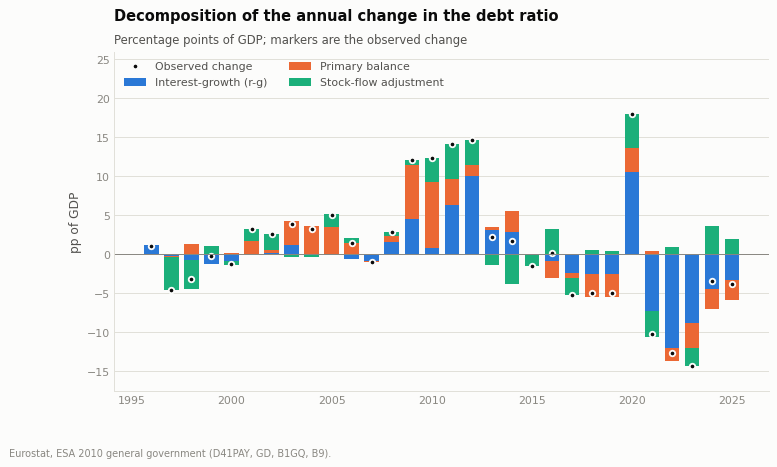

In [10]:
dynamics_labels = {
    "interest_growth_contribution_pp": ("Interest-growth (r-g)", nb.SERIES[0]),
    "primary_balance_contribution_pp": ("Primary balance", nb.SERIES[1]),
    "stock_flow_adjustment_pp": ("Stock-flow adjustment", nb.SERIES[2]),
}

fig, ax = nb.figure(height=5.0)
years = dynamics.index.to_numpy()
positive = np.zeros(len(dynamics))
negative = np.zeros(len(dynamics))
for column, (label, color) in dynamics_labels.items():
    series = dynamics[column].to_numpy()
    base = np.where(series >= 0, positive, negative)
    ax.bar(years, series, bottom=base, color=color, width=0.72, label=label)
    positive = positive + np.where(series >= 0, series, 0.0)
    negative = negative + np.where(series < 0, series, 0.0)

ax.plot(
    years,
    dynamics["observed_debt_ratio_change_pp"],
    color=nb.INK,
    linewidth=0,
    marker="o",
    markersize=4.5,
    markeredgecolor=nb.SURFACE,
    markeredgewidth=1.5,
    label="Observed change",
)
ax.axhline(0, color=nb.MUTED, linewidth=0.8)
nb.headroom(ax, top=1.32, bottom=1.10)
ax.legend(loc="upper left", ncol=2)
nb.finish(
    ax,
    title="Decomposition of the annual change in the debt ratio",
    subtitle="Percentage points of GDP; markers are the observed change",
    ylabel="pp of GDP",
)
plt.show()

In [11]:
debt_totals = dynamics[["observed_debt_ratio_change_pp", *dynamics_components]].sum()
debt_summary = debt_totals.rename("pp_of_gdp").to_frame()
debt_summary.index = [
    "Observed change in the debt ratio",
    "Interest-growth contribution",
    "Primary-balance contribution",
    "Stock-flow adjustment",
]
opening_year = int(dynamics.index.min()) - 1
opening_ratio = df.loc[df["year"].eq(opening_year), "debt_pct_gdp"].iloc[0]
print(
    f"Window: {int(dynamics.index.min())}-{int(dynamics.index.max())}  "
    f"debt ratio {opening_ratio:.1f}% -> "
    f"{dynamics['debt_pct_gdp'].iloc[-1]:.1f}% of GDP"
)
debt_summary

Window: 1996-2025  debt ratio 62.2% -> 89.7% of GDP


,pp_of_gdp
Observed change in the debt ratio,27.50
Interest-growth contribution,-5.96
Primary-balance contribution,23.50
Stock-flow adjustment,9.96


## 4. The interest-growth differential

$r - g$ is the switch that decides whether inherited debt grows or shrinks on
its own. Positive years require a primary surplus just to hold the ratio flat;
negative years do that work unaided. The colouring is on the sign, and the
midpoint is genuinely "nothing happens".

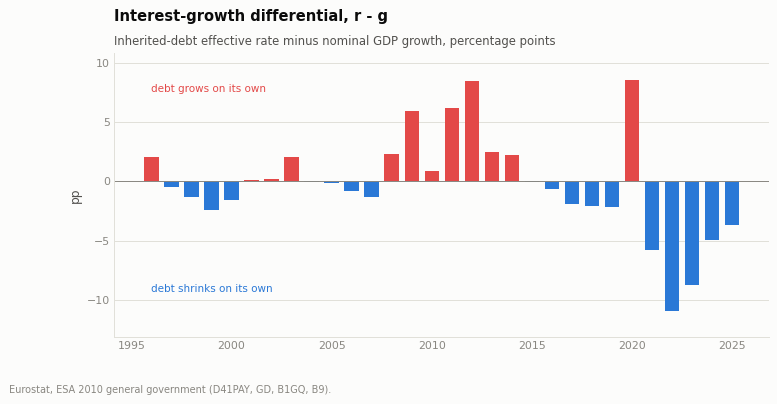

,value
years with r > g,12.00
years with r < g,18.00
mean r - g (whole period),-0.25
mean r - g (2015 onward),-2.94
mean r - g (2022 onward),-7.08


In [12]:
differential = df.dropna(subset=["interest_growth_differential_pct"]).set_index("year")
values = differential["interest_growth_differential_pct"]

fig, ax = nb.figure(height=4.2)
ax.bar(
    values.index,
    values.to_numpy(),
    color=nb.signed_colors(values.to_numpy()),
    width=0.72,
)
ax.axhline(0, color=nb.MUTED, linewidth=0.8)
nb.headroom(ax, top=1.14, bottom=1.10)
ax.annotate(
    "debt grows on its own",
    xy=(values.index.min(), values.max() * 0.88),
    fontsize=8.5,
    color=nb.POSITIVE,
    ha="left",
)
ax.annotate(
    "debt shrinks on its own",
    xy=(values.index.min(), values.min() * 0.85),
    fontsize=8.5,
    color=nb.NEGATIVE,
    ha="left",
)
nb.finish(
    ax,
    title="Interest-growth differential, r - g",
    subtitle=("Inherited-debt effective rate minus nominal GDP growth, percentage points"),
    ylabel="pp",
)
plt.show()

pd.Series(
    {
        "years with r > g": int((values > 0).sum()),
        "years with r < g": int((values < 0).sum()),
        "mean r - g (whole period)": round(values.mean(), 2),
        "mean r - g (2015 onward)": round(values.loc[values.index >= 2015].mean(), 2),
        "mean r - g (2022 onward)": round(values.loc[values.index >= 2022].mean(), 2),
    },
    name="value",
).to_frame()

## 5. The primary balance required to stabilise debt

The debt-stabilising primary balance is the surplus that exactly offsets the
interest-growth contribution. It is the *before-SFA* requirement: it assumes the
stock-flow adjustment is zero, which section 3 shows it rarely is. Plotting it
against the actual primary balance turns the identity into a reading of the
fiscal stance — above the line the ratio falls, below it the ratio rises.

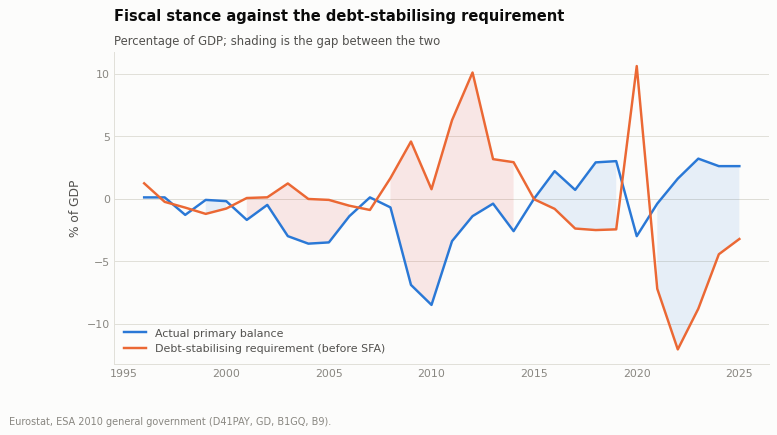

,value
years above the requirement,14.00
years below the requirement,16.00
"mean gap, whole period (pp)",-0.58
"mean gap, 2015 onward (pp)",4.43


In [13]:
stance = df.dropna(subset=["debt_stabilising_primary_balance_before_sfa_pct_gdp"]).set_index("year")
required = stance["debt_stabilising_primary_balance_before_sfa_pct_gdp"]
actual = stance["primary_balance_pct_gdp"]
gap = actual - required

fig, ax = nb.figure(height=4.6)
ax.plot(stance.index, actual, color=nb.SERIES[0], label="Actual primary balance")
ax.plot(
    stance.index,
    required,
    color=nb.SERIES[1],
    label="Debt-stabilising requirement (before SFA)",
)
ax.fill_between(
    stance.index,
    actual,
    required,
    where=gap >= 0,
    color=nb.SERIES[0],
    alpha=0.10,
    linewidth=0,
)
ax.fill_between(
    stance.index,
    actual,
    required,
    where=gap < 0,
    color=nb.SERIES[7],
    alpha=0.12,
    linewidth=0,
)
ax.axhline(0, color=nb.MUTED, linewidth=0.8, zorder=0)
ax.legend(loc="lower left")
nb.finish(
    ax,
    title="Fiscal stance against the debt-stabilising requirement",
    subtitle="Percentage of GDP; shading is the gap between the two",
    ylabel="% of GDP",
)
plt.show()

pd.Series(
    {
        "years above the requirement": int((gap >= 0).sum()),
        "years below the requirement": int((gap < 0).sum()),
        "mean gap, whole period (pp)": round(gap.mean(), 2),
        "mean gap, 2015 onward (pp)": round(gap.loc[gap.index >= 2015].mean(), 2),
    },
    name="value",
).to_frame()

## 6. Findings

Generated from the frames above.

In [14]:
full_span = spans.loc[spans["start_year"].eq(spans["start_year"].min())].iloc[-1]
recent_span = spans.loc[spans["start_year"].ne(spans["start_year"].min())]

print(f"Burden decomposition, {int(full_span['start_year'])}-{int(full_span['end_year'])}")
print(
    f"  burden {full_span['start_reconstructed_burden_pct_gdp']:.2f}% -> "
    f"{full_span['end_reconstructed_burden_pct_gdp']:.2f}% of GDP "
    f"({full_span['total_change_pp']:+.2f} pp)"
)
print(
    f"  rate effect {full_span['rate_effect_pp']:+.2f} pp, "
    f"debt-exposure effect {full_span['debt_exposure_effect_pp']:+.2f} pp "
    f"-> dominant: {full_span['dominant_effect']}"
)
if not recent_span.empty:
    row = recent_span.iloc[0]
    print(
        f"  {int(row['start_year'])}-{int(row['end_year'])}: "
        f"{row['total_change_pp']:+.2f} pp "
        f"(rate {row['rate_effect_pp']:+.2f}, "
        f"exposure {row['debt_exposure_effect_pp']:+.2f})"
    )
print(
    "  sub-periods dominated by the rate: "
    f"{int(periods['dominant_effect'].eq('rate').sum())} of {len(periods)}"
)
print()
print(f"Debt-ratio decomposition, {int(dynamics.index.min())}-{int(dynamics.index.max())}")
print(
    f"  observed {debt_totals['observed_debt_ratio_change_pp']:+.1f} pp = "
    f"r-g {debt_totals['interest_growth_contribution_pp']:+.1f} "
    f"+ primary balance {debt_totals['primary_balance_contribution_pp']:+.1f} "
    f"+ SFA {debt_totals['stock_flow_adjustment_pp']:+.1f}"
)
print(f"  years with r > g: {int((values > 0).sum())} of {len(values)}")

Burden decomposition, 1996-2025
  burden 4.83% -> 1.94% of GDP (-2.88 pp)
  rate effect -4.31 pp, debt-exposure effect +1.42 pp -> dominant: rate
  2014-2025: -2.87 pp (rate -1.64, exposure -1.22)
  sub-periods dominated by the rate: 5 of 6

Debt-ratio decomposition, 1996-2025
  observed +27.5 pp = r-g -6.0 + primary balance +23.5 + SFA +10.0
  years with r > g: 12 of 30


**Reading.** Over the full span the fall in the burden is a *price* story and
nothing else. The rate effect is larger than the total fall, and the
debt-exposure effect works in the opposite direction — average debt relative to
GDP is higher at the end than at the start, and on its own that would have
raised the burden. Cheaper debt more than paid for more debt.

The sub-periods show that this is not uniform. The crisis interval is the one
period where exposure dominates: the rate was already falling while the debt
stock climbed faster still. Every other sub-period is rate-dominated, including
the most recent one, where the direction reverses — rising rates push the burden
up and a shrinking exposure only partly offsets them. That is the first sign in
this data of the pass-through notebook 04 measures.

The debt ratio itself gives the complementary account: the interest-growth
differential was *favourable* on net across the window, so the build-up came
from cumulative primary deficits and from a large positive stock-flow
adjustment, not from the arithmetic of compounding interest.

**Caveats.** The endpoint decomposition compares two years and is blind to the
path between them, which is why the sub-periods are reported alongside the full
span rather than instead of it. The stock-flow adjustment is a residual, and a
cumulative total of this size is a question rather than an answer — it points at
crisis-era bank support, programme cash buffers, and privatisations rather than
explaining them. The debt-stabilising line in section 5 sets the adjustment to
zero, so it understates the primary balance actually needed in years when it was
positive.

**Next.** [04 — pass-through and scenarios](04_rate_pass_through_and_scenarios.ipynb)
asks how fast a change in market yields reaches the effective rate, and what
that implies for rate shocks.